In [1]:
# library(ArchR)

# proj <- loadArchRProject(path = "data/snATAC_data/ArchRProject")
# df <- as.data.frame(proj@cellColData)
# write.csv(df,'data/snATAC_data/ATAC_metadata.csv')

In [1]:
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [2]:
adata = sc.read_h5ad('data/snRNA_data/all_celltype.h5ad')

In [3]:
atac_meta = pd.read_csv('data/snATAC_data/ATAC_metadata.csv')

In [4]:
condition_order = ["Contra","COH_2w","COH_4w","COH_8w"]

/tmp/ipykernel_2844024/4103727273.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_2844024/4103727273.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


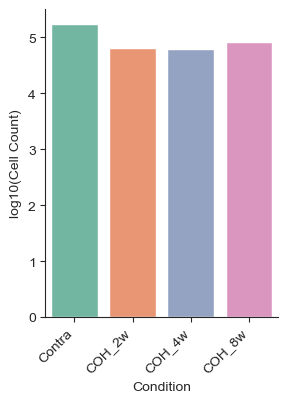

In [5]:
counts = atac_meta['Condition'].value_counts().reset_index()
counts.columns = ['condition', 'cell_count']
counts['log10_count'] = np.log10(counts['cell_count'])

with plt.rc_context({"figure.figsize": (3, 4)}):
    sns.set_style("ticks")
    ax = sns.barplot(
        data=counts, 
        x='condition', 
        y='log10_count', 
        palette="Set2", order=condition_order
    )
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    plt.ylabel('log10(Cell Count)')
    plt.xlabel('Condition')
    plt.show()

In [6]:
sample2mouse = dict(zip(adata.obs['sample'], adata.obs['mouse']))
atac_meta['mouse'] = atac_meta['Sample'].map(sample2mouse)

In [7]:
mouse_order = ["Q248","Q249","Q251","Q255","Q259","Q263","Q267","Q268","Q269"]

/tmp/ipykernel_2844024/891687979.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_2844024/891687979.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


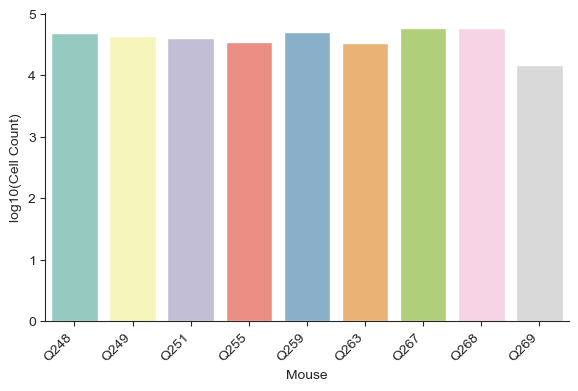

In [8]:
counts = atac_meta['mouse'].value_counts().reset_index()
counts.columns = ['mouse', 'cell_count']
counts['log10_count'] = np.log10(counts['cell_count'])

with plt.rc_context({"figure.figsize": (6.75, 4)}):
    sns.set_style("ticks")
    ax = sns.barplot(
        data=counts, 
        x='mouse', 
        y='log10_count', 
        palette="Set3",order=mouse_order
    )
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    plt.ylabel('log10(Cell Count)')
    plt.xlabel('Mouse')
    plt.show()